![Alt text](https://imgur.com/orZWHly.png=80)
source: @allison_horst https://github.com/allisonhorst/penguins

You have been asked to support a team of researchers who have been collecting data about penguins in Antartica! The data is available in csv-Format as `penguins.csv`

**Origin of this data** : Data were collected and made available by Dr. Kristen Gorman and the Palmer Station, Antarctica LTER, a member of the Long Term Ecological Research Network.

**The dataset consists of 5 columns.**

Column | Description
--- | ---
culmen_length_mm | culmen length (mm)
culmen_depth_mm | culmen depth (mm)
flipper_length_mm | flipper length (mm)
body_mass_g | body mass (g)
sex | penguin sex

Unfortunately, they have not been able to record the species of penguin, but they know that there are **at least three** species that are native to the region: **Adelie**, **Chinstrap**, and **Gentoo**.  Your task is to apply your data science skills to help them identify groups in the dataset!

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332 entries, 0 to 331
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   332 non-null    float64
 1   culmen_depth_mm    332 non-null    float64
 2   flipper_length_mm  332 non-null    float64
 3   body_mass_g        332 non-null    float64
 4   sex                332 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.1+ KB
None
       culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g
count        332.000000       332.000000         332.000000   332.000000
mean          44.021084        17.153012         200.975904  4206.475904
std            5.452462         1.960275          14.035971   806.361278
min           32.100000        13.100000         172.000000  2700.000000
25%           39.500000        15.600000         190.000000  3550.000000
50%           44.700000        17.300000         197.000000  402

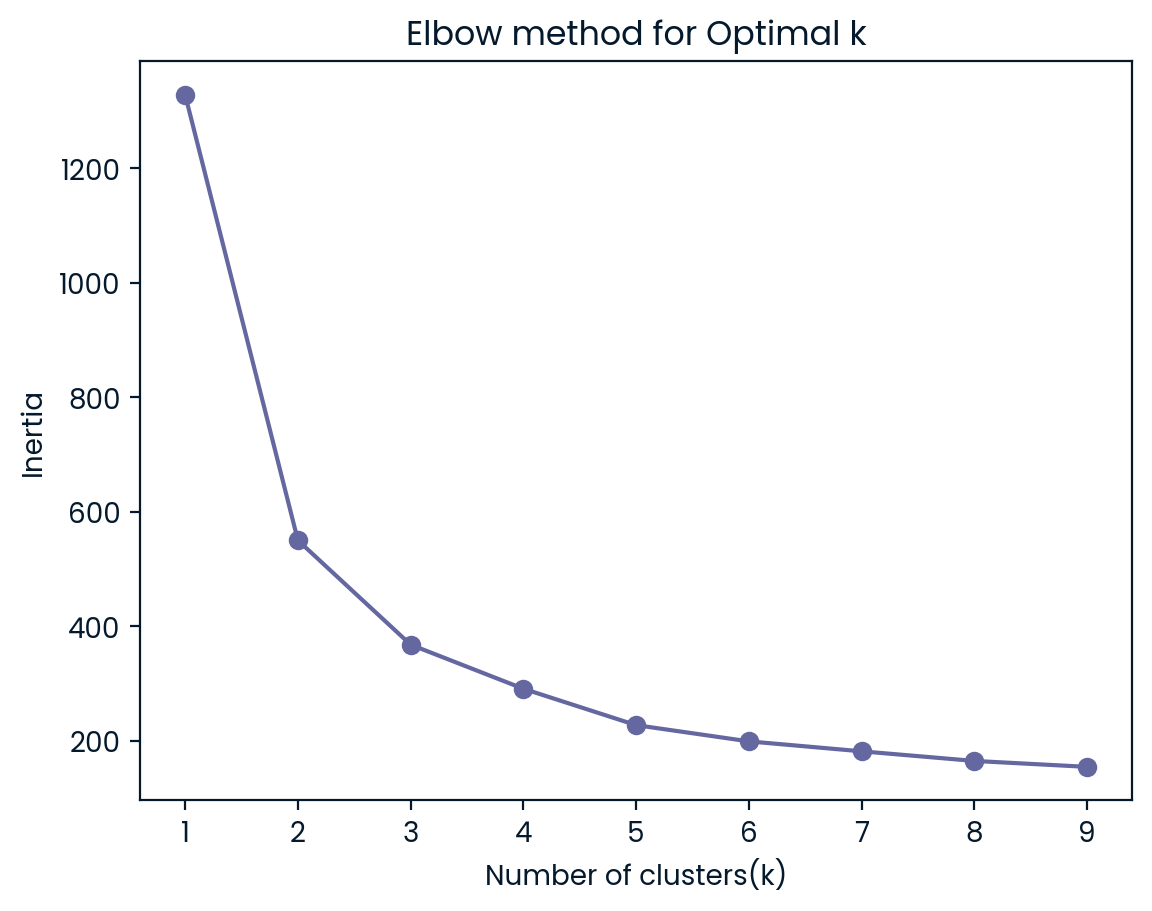


Cluster summary (stat_penguins):
   cluster  culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g
0        0         47.662353        18.748235         196.917647  3898.235294
1        1         47.568067        14.996639         217.235294  5092.436975
2        2         38.305469        18.098437         188.554688  3587.500000


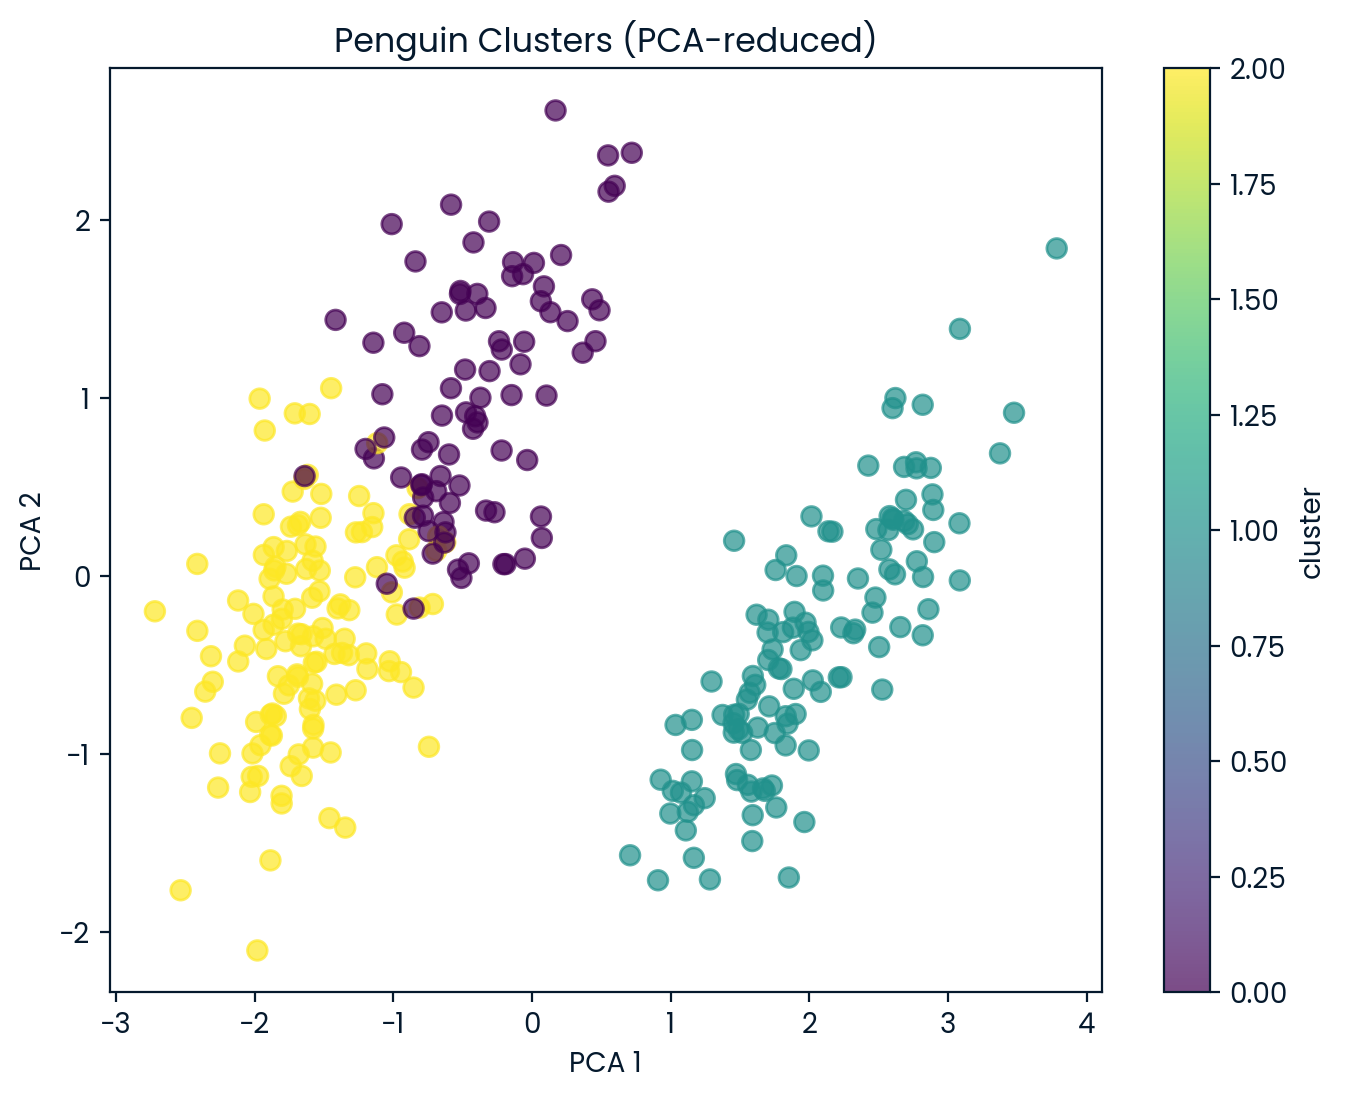

In [14]:
# Import Required Packages
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Loading and examining the dataset
penguins_df = pd.read_csv("penguins.csv")

print(penguins_df.info())
print(penguins_df.describe())
print(penguins_df.isna().sum())

numeric_cols = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
penguins_num = penguins_df[numeric_cols]

scaler = StandardScaler()
penguins_scaled = scaler.fit_transform(penguins_num)

inertia = []
K_range = range(1, 10)
for k in K_range:
    model = KMeans(n_clusters = k, random_state=42, n_init=10)
    model.fit(penguins_scaled)
    inertia.append(model.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of clusters(k)")
plt.ylabel("Inertia")
plt.title("Elbow method for Optimal k")
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42,n_init=10)
penguins_df['cluster'] = kmeans.fit_predict(penguins_scaled)

stat_penguins = penguins_df.groupby('cluster')[numeric_cols].mean().reset_index()

print("\nCluster summary (stat_penguins):")
print(stat_penguins)

pca = PCA(n_components=2)
penguins_pca = pca.fit_transform(penguins_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(penguins_pca[:,0],
            penguins_pca[:,1],
            c=penguins_df['cluster'],
            cmap='viridis',
            s=50,
            alpha=0.7)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Penguin Clusters (PCA-reduced)")
plt.colorbar(label='cluster')
plt.show()